## Recursive Feature Elimination (RFE) Overview

Recursive Feature Elimination (RFE) is a popular feature selection method that recursively removes the least important features based on a model’s learned weights or importance scores. The process involves:

1. Fitting a model (e.g., XGBoost) on the dataset.
2. Ranking features by their importance.
3. Eliminating the least important feature(s).
4. Repeating the process until the desired number of features is reached.

This algorithm helps to identify a subset of features that contributes most to the prediction variable, improving model performance and reducing overfitting.

---

### Application to Our Dataset

In our case, we applied RFE on the current dataset using an XGBoost classifier and evaluated model performance using the ROC AUC metric.

**Result**: Based on the RFE process, the algorithm selected **21 features** as the optimal number.

As shown in the graphic below, the **best ROC AUC score** was achieved when using exactly these 21 features.

---

### Interpretation

However, it is important to note that this dataset is **simulated**, not real. This has significant implications:

- Feature importance is relatively **unstable** due to the artificial nature and limited size of the dataset.
- The algorithm selected a **very small number of features**, likely because many simulated features do not carry strong signal or meaningful information.
  
**Conclusion**: In a real-world setting, with a **larger dataset** and **richer, more informative features**, we expect:
- A more stable feature selection process.
- The ability to calculate **more relevant features**.
- Better generalization and **more reliable ROC AUC performance**.



## Import Libs

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import  train_test_split,RepeatedStratifiedKFold,ShuffleSplit,cross_validate,StratifiedKFold,RandomizedSearchCV,cross_val_score,GridSearchCV
from tqdm import tqdm
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
train = pd.read_pickle('../data/train_set.pkl')

In [3]:
train.shape

(5571, 73)

In [4]:
# Some data cleaning
train = train.astype(float)
train.columns = train.columns.str.replace(r'[\[\]<>]', '_', regex=True)

In [5]:
X_train = train.drop(columns='Target')
y_train = train['Target']

In [6]:
X_train.shape,y_train.shape

((5571, 72), (5571,))

In [7]:
y_train.value_counts()

Target
0.0    3634
1.0    1937
Name: count, dtype: int64

###   Implementing Recursive feature elimination for selecting the most important features

In [8]:
select = RFE(XGBClassifier(),n_features_to_select = 1)
select.fit(X_train, np.ravel(y_train))

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).","XGBClassifier...ree=None, ...)"
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None


### Sorting the important features

In [9]:
xgb_rank_dic = {}
for i in range(len(X_train.columns)):
    xgb_rank_dic[X_train.columns[i]] = select.ranking_[i]
sel_features = sorted(xgb_rank_dic, key=xgb_rank_dic.get)

100%|██████████| 72/72 [00:41<00:00,  1.75it/s]


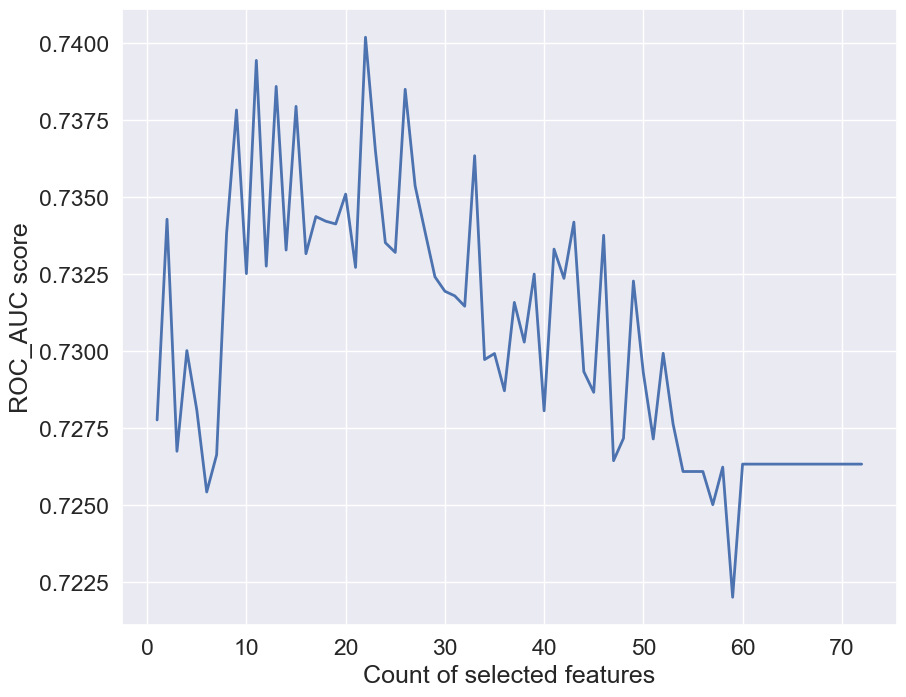

In [10]:
xgb_roc_auc = []
for i in tqdm(range(1,len(sel_features)+1)):
    xgb_roc_auc_mean = []
    features = sel_features[:i]
    X_train_copy = X_train[features]
    xg_b = model = XGBClassifier(verbosity=0)
    skf = StratifiedKFold(n_splits = 3)
    for train_index, valid_index in skf.split(X_train_copy, y_train):
        X_tr, X_valid = X_train_copy.iloc[train_index], X_train_copy.iloc[valid_index]
        y_tr, y_valid = y_train.iloc[train_index], y_train.iloc[valid_index]
        xg_b.fit(X_tr, y_tr,
                 #verbose_eval = 1,
                 #early_stopping_rounds = 100,
                 eval_set = [(X_valid, y_valid)], 
                 verbose = 0)
                 #use_best_model = False)
        xgb_roc_auc_mean.append(roc_auc_score(y_valid, xg_b.predict_proba(X_valid)[:,1]))
    xgb_roc_auc.append(np.mean(xgb_roc_auc_mean))


sns.set(font_scale=1.5)
sns.set_color_codes("muted")
plt.figure(figsize=(10, 8))
lw = 2
plt.plot(range(1,len(sel_features)+1), xgb_roc_auc, lw=lw, label='ROC curve ')
plt.xlabel('Count of selected features')
plt.ylabel('ROC_AUC score')
plt.show()

In [11]:
max_index = np.argmax(xgb_roc_auc)
max_value = xgb_roc_auc[max_index]

In [12]:
max_index

np.int64(21)

In [13]:
sel_features[:21]

['PreviouslyDefaulted',
 'Txn_Avg',
 'Txn_Sum_6M',
 'Hist_DaysSinceLastLoan',
 'LoanAmountToTxnNetRatio',
 'Amount',
 'Hist_MonthsSinceFirstLoan',
 'AgeToLoanRatio',
 'DaysSinceRegistration',
 'Txn_Sum_3M',
 'Hist_LoanFrequencyPerYear',
 'ApplicationWeekday',
 'Hist_ShortTermLoanShare',
 'Hist_AvgLoanGap',
 'Txn_Count',
 'Hist_MeanEMIs',
 'OutgoingToIncomingRatio',
 'Txn_LastDaysAgo',
 'Hist_MaxAmount',
 'RecentOutRatio',
 'CustomerAgeAtApplication']

In [14]:
import json

with open('../data/selected_features.json', 'w') as f:
    json.dump(sel_features[:21], f, indent=4)
